In [19]:
import xtrack as xt
import numpy as np
import os
import matplotlib.pyplot  as plt
import matplotlib.patches as patches
import xpart as xp
import xobjects as xo

import useful_functions

In [34]:
#Pre-defined params
# %% create environment, parameters and first simple cells & structures
#reupload

pdr = xt.Environment()
pdr.particle_ref = xt.Particles(kinetic_energy0=2.86e9, mass0 = xt.ELECTRON_MASS_EV)

E0 = 2.86e9; VRF = 2.000e6 # beam energy in eV and RF voltage (1 cavity) in V

pdr.vars({'l_cell': 3.45,'l_bend': 0.40,'l_bendDS': 0.55,'dl_noben': 0.25, 'l_quad': 0.30,
  'l_drift': '(l_cell - 2*l_bend - 2*l_quad)/4','dl_drift': -0.15, 'dl_trans': 0.00,
  'l_doub':  0.25, 'l_tripl': 3.00, 'l_trips': 0.40})

pdr.vars({'N_cells_S': 8,'hBarc' : '6.283185307/(6*(2*N_cells_S*l_bend + l_bendDS))',
  'kQFarc': 2.9478, 'kQDarc':-2.9231,'kQFarcM': 2.8846, 'kQDarcM':-2.7567, 
  'kQFDS': 2.8042, 'kQDDS':-2.2858, 'kQFDoub': 3.9170, 'kQDDoub':-2.5190, 
  'kQFtr': 4.4429, 'kQDtr':-2.4723 } )

U0 = (0.88463e-31)*E0**4*(2.*np.pi)/(6*(2*pdr['N_cells_S']*pdr['l_bend'] + pdr['l_bendDS']) )

pdr.new('Bend', xt.Bend, length='l_bend', angle='hBarc*l_bend', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bend/2', edge_exit_angle='hBarc*l_bend/2')
pdr.new('QFarc',  xt.Quadrupole, length='l_quad',    k1='kQFarc' )
pdr.new('QFarcH', xt.Quadrupole, length='l_quad/2.', k1='kQFarc' )
pdr.new('Drarc',  xt.Drift,      length='l_drift' )
pdr.new('DrarcS', xt.Drift,      length='l_drift + dl_drift' )
pdr.new('QDarc',  xt.Quadrupole, length='l_quad',    k1='kQDarc' )
pdr.new('QFarcM', xt.Quadrupole, length='l_quad',    k1='kQFarcM' )
pdr.new('QDarcM', xt.Quadrupole, length='l_quad',    k1='kQDarcM' )
pdr.new('BendDS', xt.Bend, length='l_bendDS', angle='hBarc*l_bendDS', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bendDS/2', edge_exit_angle='hBarc*l_bendDS/2')
pdr.new('QFDS',   xt.Quadrupole, length='l_quad',    k1='kQFDS' )
pdr.new('QDDS',   xt.Quadrupole, length='l_quad',    k1='kQDDS' )
pdr.new('DrDSL',  xt.Drift,      length='2*l_drift + l_bend + dl_noben' )
pdr.new('DrTrans',xt.Drift,      length='l_drift + dl_trans' )
pdr.new('QFDoub', xt.Quadrupole, length='l_quad',    k1='kQFDoub' )
pdr.new('QDDoub', xt.Quadrupole, length='l_quad',    k1='kQDDoub' )
pdr.new('DrDoub', xt.Drift,      length='l_doub' )

pdr.new('QFtr',    xt.Quadrupole, length='l_quad',    k1='kQFtr' )
pdr.new('QFtrH',   xt.Quadrupole, length='l_quad/2.', k1='kQFtr' )
pdr.new('QDtr',    xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('QDtrH',   xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('DrTripl', xt.Drift,      length='l_tripl' )
pdr.new('DrTrips', xt.Drift,      length='l_trips' )

#Add any new variables and structures here
pdr['l_sext']=0.1
pdr['kSF']=80.523647
pdr['kSD']=-114.825918

pdr.new('Drarc2', xt.Drift, length='(l_drift-l_sext)/2')

pdr.new('SFDS', xt.Sextupole, length='l_sext',k2='kSF')
pdr.new('SDDS', xt.Sextupole, length='l_sext',k2='kSD')

'SDDS'

In [26]:
#makesextant function
def makesextant ( name, fall ):
    comps = [ ]
    comps = comps + [pdr.new('Drarc0_'+name+str(0),'Drarc2'),pdr.new('SFA0_'+name+str(0),'SFDS')]
    for ind in range( pdr['N_cells_S'] - 1 ):  # regular arc cells
       
       comps = comps + [ pdr.new('Drarc1_'+ name + str(ind+1), 'Drarc2'), pdr.new('Bend1_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc2_'+ name + str(ind+1), 'Drarc'), pdr.new('QDA_' + name + str(ind+1), 'QDarc')]
       comps = comps + [pdr.new('Drarc3_'+name+str(ind+1),'Drarc2'),pdr.new('SDA_'+name+str(ind+1),'SDDS')]
       comps = comps + [ pdr.new('Drarc4_'+ name + str(ind+1), 'Drarc2'), pdr.new('Bend2_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc5_'+ name + str(ind+1), 'Drarc'), pdr.new('QFA_' + name + str(ind), 'QFarc')]
       comps = comps + [pdr.new('Drarc6_'+name+str(ind+1),'Drarc2'),pdr.new('SFA_'+name+str(ind+1),'SFDS')]
    # Replace last QF and add last arc cell (matching quads) "by hand"
    comps[-3] = pdr.new('QFAM_' + name + str(pdr['N_cells_S']), 'QFarcM' )
    comps[-1] = pdr.new('SFAM_' + name + str(pdr['N_cells_S']), 'SFDS')
    comps = comps + [pdr.new('DrarcS1_'+ name + str(ind+1), 'Drarc2'),pdr.new('Bend1_' + name + str(pdr['N_cells_S']), 'Bend')]
    comps = comps + [pdr.new('Drarc7_'+ name + str(ind+1), 'Drarc'), pdr.new('QDAM_' + name + str(pdr['N_cells_S']), 'QDarcM')]
    comps = comps + [pdr.new('Drarc75_'+name+str(ind+1),'Drarc2'),pdr.new('SDAM_'+name+str(ind+1),'SDDS')]
    comps = comps + [pdr.new('Drarc8_'+ name + str(ind+1), 'Drarc2'), pdr.new('Bend2_' + name + str(pdr['N_cells_S']), 'Bend')]
    # Add dispersion suppressor
    comps = comps + [pdr.new('Drarc9_'+ name + str(ind+1), 'Drarc'), pdr.new('QFDS_' + name, 'QFDS') ]
    comps = comps + [pdr.new('DrDSL1_'+ name + str(ind+1), 'DrDSL'), pdr.new('QDDS_' + name, 'QDDS') ]
    comps = comps + [pdr.new('Drarc10_'+ name + str(ind+1), 'Drarc'), pdr.new('BendDS_' + name, 'BendDS')]
    # Add doublet matching 
    comps = comps + [pdr.new('DrTrans1_'+ name + str(ind+1), 'DrTrans'), pdr.new('QFDoub_' + name, 'QFDoub')]
    comps = comps + [pdr.new('DrDoub1_'+ name + str(ind+1), 'DrDoub'), pdr.new('QDDoub_' + name, 'QDDoub')]   
    comps = comps + [pdr.new('DrTripl1_'+ name + str(ind+1), 'DrTripl'), pdr.new('QDTrip_' + name + '1', 'QDtr')]  
    if fall == 'symm':
       comps = [ pdr.new('QFA_' + name + 'CH', 'QFarcH' ) ] + comps
       comps = comps + [ pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2H', 'QFtrH')]
    elif fall == 'right':
       comps = [ pdr.new('QFA_' + name + 'C', 'QFarc'  ) ] + comps + [ pdr.place('DrTrips') ]
    elif fall == 'left':
       comps = comps + [pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2', 'QFtr') ]
       comps = list( reversed(comps) )
    else:
       print( '=====> choice for sextant version incorrect <=====' )
       quit()
    return pdr.new_line( components = comps )

In [4]:
'''def makesextant(name, fall):

    comps=[]

    for ind in range(pdr['N_cells_S'] - 1):

        comps += [
            pdr.new('Drarc1_'+name+str(ind+1), 'Drarc'),
            pdr.new('Bend1_'+name+str(ind+1), 'Bend'),

            # centered SD sextupole
            pdr.new('Drarc2_'+name+str(ind+1), 'Drarc2'),
            pdr.new('SDA_'+name+str(ind+1), 'SDDS'),
            pdr.new('Drarc3_'+name+str(ind+1), 'Drarc2'),
            pdr.new('QDA_'+name+str(ind+1), 'QDarc'),

            pdr.new('Drarc4_'+name+str(ind+1), 'Drarc'),
            pdr.new('Bend2_'+name+str(ind+1), 'Bend'),

            # centered SF sextupole
            pdr.new('Drarc5_'+name+str(ind+1), 'Drarc2'),
            pdr.new('SFA_'+name+str(ind+1), 'SFDS'),
            pdr.new('Drarc6_'+name+str(ind+1), 'Drarc2'),
            pdr.new('QFA_'+name+str(ind+1), 'QFarc'),
        ]

    # --- last arc cell ---
    comps[-1]= pdr.new('QFAM' + name + str(pdr['N_cells_S']), 'QFarcM' )
    comps += [
        pdr.new('DrarcS1_'+name+str(ind+1), 'DrarcS'),
        pdr.new('Bend1_'+name+str(pdr['N_cells_S']), 'Bend'),

        pdr.new('Drarc7_'+name+str(ind+1), 'Drarc2'),
        pdr.new('SDAM_'+name+str(ind+1), 'SDDS'),  # sext before QD

        pdr.new('Drarc8_'+name+str(ind+1), 'Drarc'),
        pdr.new('QDAM_'+name+str(pdr['N_cells_S']), 'QDarcM'),

        pdr.new('Drarc9_'+name+str(ind+1), 'Drarc'),
        pdr.new('Bend2_'+name+str(pdr['N_cells_S']), 'Bend'),
    ]

    # --- dispersion suppressor ---

    comps += [
        pdr.new('Drarc10_'+name+str(ind+1), 'Drarc'),
        pdr.new('QFDS_'+name, 'QFDS'),

        pdr.new('DrDSL1_'+name+str(ind+1), 'DrDSL'),
        pdr.new('QDDS_'+name, 'QDDS'),

        pdr.new('Drarc11_'+name+str(ind+1), 'Drarc'),
        pdr.new('BendDS_'+name, 'BendDS'),
    ]

    # --- matching section ---

    comps += [
        pdr.new('DrTrans1_'+name+str(ind+1), 'DrTrans'),
        pdr.new('QFDoub_'+name, 'QFDoub'),

        pdr.new('DrDoub1_'+name+str(ind+1), 'DrDoub'),
        pdr.new('QDDoub_'+name, 'QDDoub'),

        pdr.new('DrTripl1_'+name+str(ind+1), 'DrTripl'),
        pdr.new('QDTrip_'+name+'1', 'QDtr'),
    ]

    # --- sextant endings ---

    if fall == 'symm':
        comps = [pdr.new('QFA_'+name+'CH', 'QFarcH')] + comps
        comps += [pdr.place('DrTrips'), pdr.new('QFTripC_'+name+'2H', 'QFtrH')]

    elif fall == 'right':
        comps = [pdr.new('QFA_'+name+'C', 'QFarc')] + comps + [pdr.place('DrTrips')]

    elif fall == 'left':
        comps += [pdr.place('DrTrips'), pdr.new('QFTripC_'+name+'2', 'QFtr')]
        comps = list(reversed(comps))

    else:
        print('=====> choice for sextant version incorrect <=====')
        quit()

    return pdr.new_line(components=comps)'''

"def makesextant(name, fall):\n\n    comps=[]\n\n    for ind in range(pdr['N_cells_S'] - 1):\n\n        comps += [\n            pdr.new('Drarc1_'+name+str(ind+1), 'Drarc'),\n            pdr.new('Bend1_'+name+str(ind+1), 'Bend'),\n\n            # centered SD sextupole\n            pdr.new('Drarc2_'+name+str(ind+1), 'Drarc2'),\n            pdr.new('SDA_'+name+str(ind+1), 'SDDS'),\n            pdr.new('Drarc3_'+name+str(ind+1), 'Drarc2'),\n            pdr.new('QDA_'+name+str(ind+1), 'QDarc'),\n\n            pdr.new('Drarc4_'+name+str(ind+1), 'Drarc'),\n            pdr.new('Bend2_'+name+str(ind+1), 'Bend'),\n\n            # centered SF sextupole\n            pdr.new('Drarc5_'+name+str(ind+1), 'Drarc2'),\n            pdr.new('SFA_'+name+str(ind+1), 'SFDS'),\n            pdr.new('Drarc6_'+name+str(ind+1), 'Drarc2'),\n            pdr.new('QFA_'+name+str(ind+1), 'QFarc'),\n        ]\n\n    # --- last arc cell ---\n    comps[-1]= pdr.new('QFAM' + name + str(pdr['N_cells_S']), 'QFarcM' )\n    co

Slicing line: 100%|██████████| 109/109 [00:00<00:00, 148579.50it/s]
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


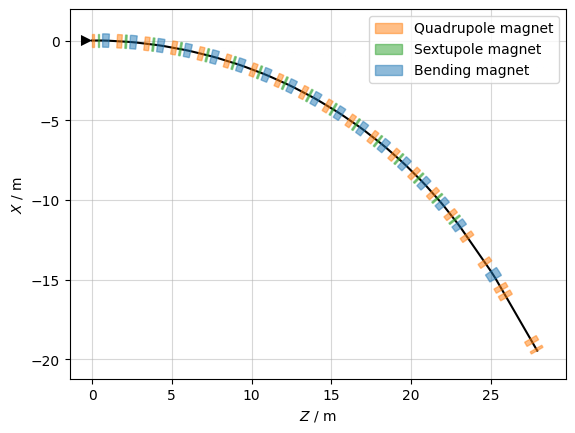

In [27]:
arc1R = makesextant( 'xR', 'symm' )
arc1R_sliced = arc1R.select()
arc1R_sliced.cut_at_s( np.linspace(.05, arc1R.get_length()-.05, int(arc1R.get_length()/.05-.5)) )
arc1R.insert( pdr.new('CtrS1_xR1', xt.Marker ), at='(l_tripl+l_quad)/2', from_='QDDoub_xR' )
arc1R.survey().plot()

In [ ]:
def addSketchBL( acc_tw, acc, lims, limy1, limy2, scK1 ):
    fig, ax = plt.subplots( 3, 1, figsize=(12, 8), height_ratios=(1.8, 4, 3) )
    axl, axp, axt = ax
    axp.sharex( axl )
    fig.subplots_adjust( hspace=0.0, top=1.0, bottom=0.0, left=.1 )

    axp.set_xlabel( 'Position s [m]' )
    axp.set_ylim( limy1 )
    axp.set_ylabel( r'$\beta_x$, $\beta_y$ [m]' )
      
    indm = int( np.array([(np.sign(lims[-1]-x) + 1)/2 for x in acc_tw.s ]).sum() )
    axp.plot( acc_tw.s[:indm], acc_tw.betx[:indm], color='black', linestyle=(0, (10, 0)) )
    axp.plot( acc_tw.s[:indm], acc_tw.bety[:indm], color='black', linestyle=(0, (6, 4)) )
    axp2 = axp.twinx()
    axp2.set_ylim( limy2 )
    axp2.set_ylabel( r'$D_x$, $D_y$ [m]' )
    axp2.plot( acc_tw.s[:indm], acc_tw.dx[:indm], color='black', linestyle=(0, (5, 3, 1, 3)) )
    axp2.plot( acc_tw.s[:indm], acc_tw.dy[:indm] )
    axp.set_xlim( lims )
    
    axl.set_ylim( -.30, 1.00 )
    axl.axis( 'off' )
    tab_pan = acc.get_table(attr=True).to_pandas()
    for ind in range( len(tab_pan.T.columns) -1 ):
        if tab_pan['element_type'][ind].find('Drift') >= 0:
           axl.plot( [tab_pan['s'][ind], tab_pan['s'][ind+1]], [0, 0], color='black' )
        if tab_pan['element_type'][ind].find('Bend') >= 0:
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], -0.08), 
               tab_pan['s'][ind+1] - tab_pan['s'][ind], 0.16, fill=True, color='tab:blue' ) ) 
        if tab_pan['element_type'][ind].find('Quad') >= 0:
           kstr = scK1*tab_pan['k1l'][ind]/tab_pan['length'][ind]
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], min(0.0, kstr)),
               tab_pan['s'][ind+1] - tab_pan['s'][ind], abs(kstr), fill=True, color='tab:orange' ) )    
        if tab_pan['element_type'][ind].find('Sext')>=0:
           kstr = scK1*tab_pan['k2l'][ind]/tab_pan['length'][ind]
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], min(0.0, kstr)),
               tab_pan['s'][ind+1] - tab_pan['s'][ind], abs(kstr), fill=True, color='tab:green' ) )      
    axp.plot( [acc.get_length(), acc.get_length()], limy1, color='black', 
              linestyle=(0, (8, 8)), linewidth=.5 )

    axt.axis( 'off' )
    axt.set_xlim( -.3, 3.8 ); axt.set_ylim( 0, 1 )
    return axt

# Routine generating graphical and text output describing the ring    
def SpuckParsAus( acc_tw, acc, lims, limy1, limy2, scK1, grname='NoGraph' ):
    axt = addSketchBL( acc_tw, acc, lims, limy1, limy2, scK1 )
    axt.text( 0.0, .7, f'C ={3*acc_tw.circumference:8.4f} m', horizontalalignment='left' )
    axt.text( 1.0, .7, f'T ={3e6*acc_tw.T_rev0:8.4f} us', horizontalalignment='left')
    axt.text( 2.0, .7, r'($Q_x$, $Q_y$)' + f' = ({3*acc_tw.qx:9.5f}, {3*acc_tw.qy:9.5f})', 
        horizontalalignment='left')
    pos=0
    for item in pdr.vars.keys()[2:]:
       print( "'" + item + f"': {pdr[item]:8.4f}," )
       axt.text( pos%4 , .6 - .1*int( pos/4 ),
          "'" + item + f"': {pdr[item]:8.4f},", horizontalalignment='left' )
       pos += 1
    if grname != 'NoGraph': 
       if grname in os.listdir( '/home/mwatson/Documents/laughing-octo-bassoon'):
          print( ' Error: file ' + grname + ' exists <<<<<<<<<<<================' )
       else:
          plt.savefig( '/home/mwatson/Documents/laughing-octo-bassoon' + grname )
    tab_pan = acc.get_table(attr=True).to_pandas()
    print('  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)')
    for ind in range( len(tab_pan.T.columns) - 1 ):
       eltyp = tab_pan['element_type'][ind]
       if eltyp.find('Drift') < 0:
          elnam = tab_pan['name'][ind]
          if ind < 1: sin = '  0.0000'
          else: sin = f"{tab_pan['length'][ind-1]:8.4f}"         
          k1expr = pdr.element_refs[elnam].k1._expr
          if k1expr == None: k1expr = ' None'
          else: k1expr = str(k1expr)[5:-1]
          print(  "  " + elnam.ljust( 12 ) + eltyp.ljust(12)[:8] + f" {tab_pan['length'][ind]:7.4f} " + 
               f"{tab_pan['s'][ind]:8.4f} {tab_pan['s'][ind+1]:8.4f} " + sin +
               f"{tab_pan['length'][ind+1]:8.4f} " + k1expr.ljust(9) + 
               f"= {tab_pan['k1l'][ind]/max(tab_pan['length'][ind],1e-6):7.4f}  " )

Slicing line: 100%|██████████| 218/218 [00:00<00:00, 4444.78it/s]


Successfully saved to: /home/mwatson/Documents/laughing-octo-bassoon/Standard.pdf
  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)
  QFA_PRCH    Quadrupo  0.1500   0.0000   0.1500   0.0000  0.2063  None    =  2.9478  
  SFA0_PR0    Sextupol  0.1000   0.3563   0.4563   0.2063  0.2063  None    =  0.0000  
  Bend1_PR1   Bend      0.4000   0.6625   1.0625   0.2063  0.5125  None    =  0.0000  
  QDA_PR1     Quadrupo  0.3000   1.5750   1.8750   0.5125  0.2063  None    = -2.9231  
  SDA_PR1     Sextupol  0.1000   2.0813   2.1813   0.2063  0.2063  None    =  0.0000  
  Bend2_PR1   Bend      0.4000   2.3875   2.7875   0.2063  0.5125  None    =  0.0000  
  QFA_PR0     Quadrupo  0.3000   3.3000   3.6000   0.5125  0.2063  None    =  2.9478  
  SFA_PR1     Sextupol  0.1000   3.8063   3.9063   0.2063  0.2063  None    =  0.0000  
  Bend1_PR2   Bend      0.4000   4.1125   4.5125   0.2063  0.5125  None    =  0.0000  
  QDA_PR2     Quadrupo  0.3000   5.0250   5.3250   0.512

Slicing line: 100%|██████████| 648/648 [00:00<00:00, 236032.04it/s]


Horizontal Chromaticity (dqx): 0.0008
Vertical Chromaticity (dqy):   -0.0944
Max Betx: 9.84 m
Max Bety: 7.04 m


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



Approximatif harmonics  288.00000 and fRF =399723270.95537
  Length of short drifts:   0.513 m
=>Circumference 216.0000 and revolution  0.72050 us
  Energy loss per turn from me  891804.40 and twiss   892439.31 and diff     634.91
  Vertical damping time   6410.541 and   6409.399 turns
  Working point  15.64932 and  14.76276
  Equilibrium emmittances 2.821e-08, 1.086e-54 and 1.273e-05
  Equilibrium polarization 0.92376 and time     780.03 s


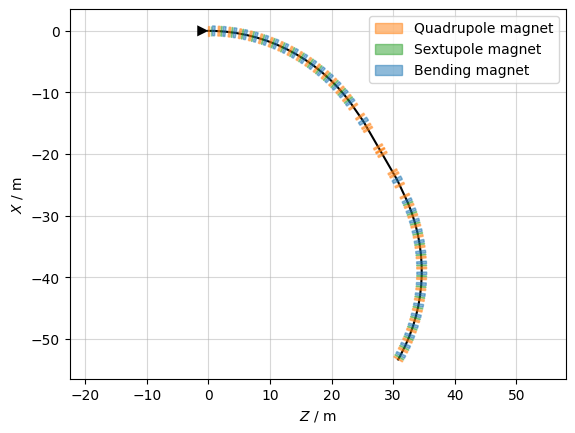

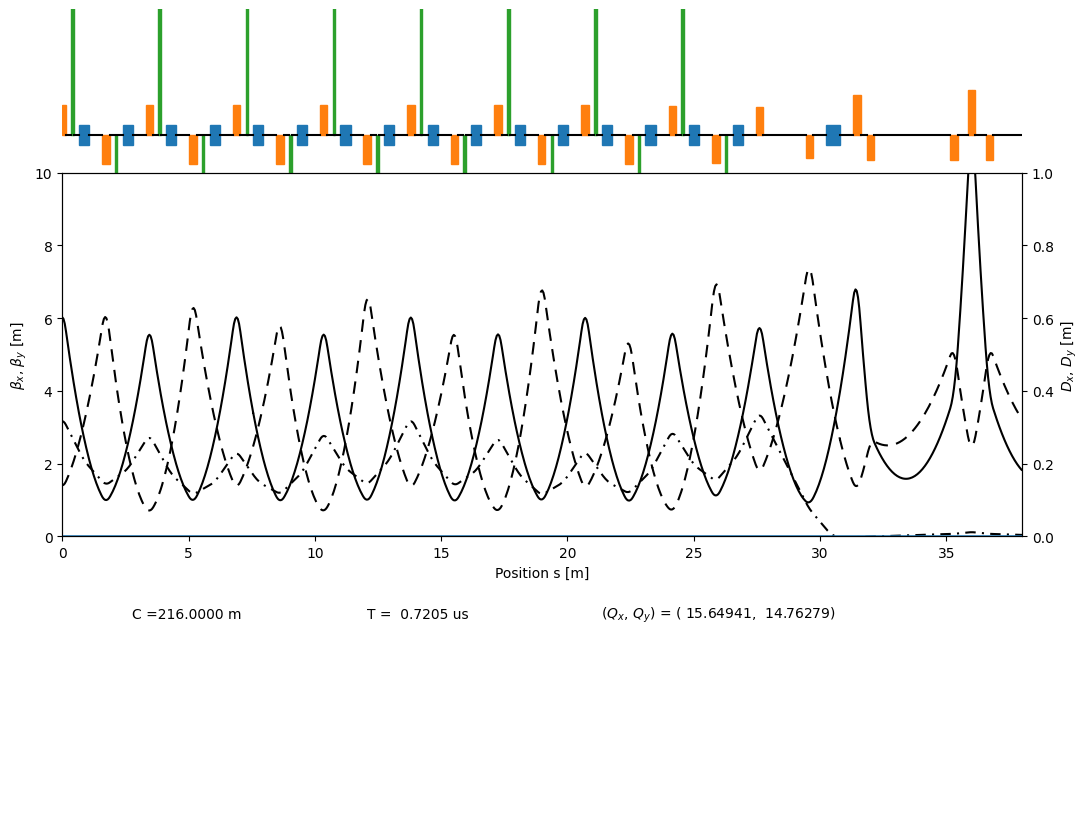

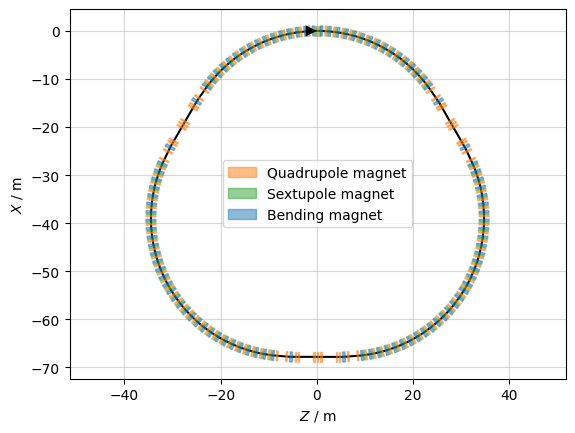

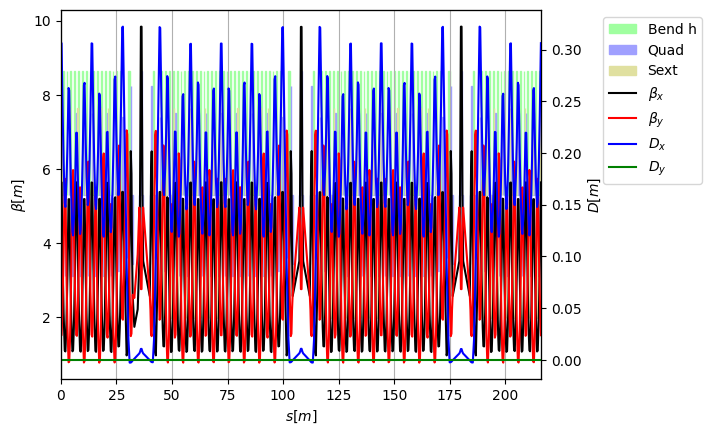

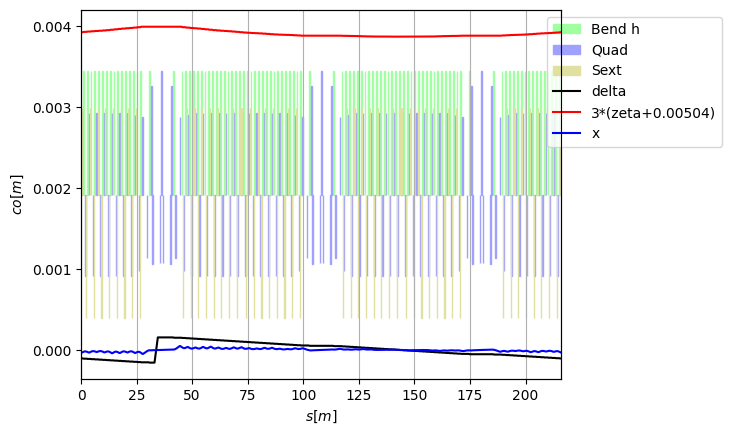

In [ ]:
# One period from center of arc to center of arc
period = makesextant( 'PR', 'symm') + ( -makesextant( 'PL', 'symm') )
period.survey().plot()
period_sliced = period.select()
period_sliced.cut_at_s( np.linspace(.05, period.get_length()-.05, int(period.get_length()/.05-.5)) )

# Full ring without X-poles, RF and wigglers
ring  = makesextant( '1R', 'right') + makesextant( '2L', 'left') + makesextant( '2R', 'right') + makesextant( '3L', 'left') + makesextant( '3R', 'right') + makesextant( '1L', 'left')

def ChromCorrect(ksf, ksd, MakePlot=False):
        
    opt_chrom = ring.match(
        solve=False,
        verbose=False,
        method='4d',
        vary=xt.VaryList([ksf, ksd], step=1e-3),
        targets=xt.TargetSet(dqx=0., dqy=0., tol=1e-3))
    opt_chrom.target_status()
    opt_chrom.run_jacobian(n_steps=100)
    opt_chrom.target_status()
    # Print the final matched strengths

    print(f"Matched kSF: {pdr.vars['kSF']._get_value():.6f}")
    print(f"Matched kSD: {pdr.vars['kSD']._get_value():.6f}")   

#useful_functions.ChromCorrect(ring,'kSF', 'kSD')
#useful_functions.SpuckParsAus( period_sliced.twiss(method='4d'), period,(0., 38.), (0., 10.), (0., 1.), .08, "Standard.pdf" )



fRev = 1./(ring.twiss(method='4d').T_rev0)
fRF  = fRev*round(4.e8/fRev)  # at integer harmonics and close to 400 MHz
pdr.new('RFCav',  xt.Cavity, length=1.5, frequency=fRF, voltage=VRF, 
        lag=(180/np.pi)*(np.pi - np.arcsin(U0/VRF)) - 1.8 ) 
ring.insert( pdr.new('RFCav_1', 'RFCav'), at='(l_tripl+l_quad)/2', from_='QDDoub_1R' )
ring.configure_radiation(model='mean')
ring.configure_bend_model(edge='full')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
                   spin=True, polarization=True )
print(f"Horizontal Chromaticity (dqx): {ring_tw.dqx:.4f}")
print(f"Vertical Chromaticity (dqy):   {ring_tw.dqy:.4f}")
print(f"Max Betx: {max(ring_tw.betx):.2f} m")
print(f"Max Bety: {max(ring_tw.bety):.2f} m")

ring.survey().plot()

ring_tw.plot()
ring_tw.plot('delta 3*(zeta+0.00504) x')


print( f'\nApproximatif harmonics {fRF/fRev:10.5f} and fRF ={fRF:8.5f}' )
# print( ring_tw.keys() )
print( f"  Length of short drifts: {pdr['l_drift']:7.3f} m" )
# print( ring_tw.keys() )
print( f'=>Circumference {ring_tw.circumference:8.4f} and revolution {1e6*ring_tw.T_rev0:8.5f} us' )
print( f'  Energy loss per turn from me {U0:10.2f} and twiss' + 
       f'  {ring_tw.eneloss_turn:10.2f} and diff {ring_tw.eneloss_turn-U0:10.2f}' )
print( f'  Vertical damping time {1/ring_tw.damping_constants_turns[1]:10.3f} and {2*E0/ring_tw.eneloss_turn:10.3f} turns' )
print( f'  Working point{ring_tw.qx:10.5f} and{ring_tw.qy:10.5f}')
print( f'  Equilibrium emmittances{ring_tw.eq_gemitt_x:10.3e},{ring_tw.eq_gemitt_y:10.3e} and{ring_tw.eq_gemitt_zeta:10.3e}'  )
print( f'  Equilibrium polarization{ring_tw.spin_polarization_eq:8.5f} and time {ring_tw.spin_t_pol_buildup_s:10.2f} s')

In [8]:
# %% Simple test of tracking with synchrotron radiation - takes some time
ring.configure_radiation(model='mean')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True)
#ring_tw.plot()
#print( ring_tw.keys() )
print( f' Energy loss per turn from twiss {ring_tw.eneloss_turn:10.2f} and me {U0:10.2f}')
print( 1/ring_tw.damping_constants_turns )
print( 2*E0/ring_tw.eneloss_turn )

npts = 200
epsx, epsy, epsl = 1.0e-7, 1.0e-7, 1.0e-4  # starting with somewhat large emittances
betxin, alfxin  = ring_tw.betx[0], ring_tw.alfx[0] 
xin, pxin       = ring_tw.x[0], ring_tw.px[0]
dxin, dpxin     = ring_tw.dx[0], ring_tw.dpx[0]
betyin, alfyin  = ring_tw.bety[0], ring_tw.alfy[0] 
yin, pyin       = ring_tw.y[0], ring_tw.py[0]   # should be zero for perfect case
#epsx, epsl      = 2.0*ring_tw.eq_gemitt_x, 2.0*ring_tw.eq_gemitt_zeta
betlin          = ring_tw.bets0
zetain, deltain = ring_tw.zeta[0], ring_tw.delta[0]
print( f'At reference location: D ={dxin:7.4f} m, Dp ={dpxin:7.4f},' +
       f' betx ={betxin:7.4f} m, alfx ={alfxin:7.4f},' + 
       f' betl ={betlin:7.4f} m ')

normat = np.array([
    [(epsx*betxin)**.5,         0,                 0,  0, 0, dxin*(epsl/betlin)**.5],
    [-alfxin*(epsx/betxin)**.5, (epsx/betxin)**.5, 0,  0, 0, dpxin*(epsl/betlin)**.5],
    [0,  0,  (epsx*betyin)**.5,         0,                 0, 0],
    [0,  0,  -alfyin*(epsx/betyin)**.5, (epsx/betyin)**.5, 0, 0],
    [0, 0, 0, 0, (epsl*betlin)**.5, 0                ],
    [0, 0, 0, 0, 0,                 (epsl/betlin)**.5]               
    ])

parts = np.array([
     [xin, pxin, yin, pyin, zetain, deltain] + normat@np.random.randn(6) 
         for ind in range(npts) ]).T
# quit()
p2 = xt.Particles(kinetic_energy0 = 2860.e6, mass0 = xt.ELECTRON_MASS_EV,
                  x    = parts[0], px   = parts[1],
                  y    = parts[2], py   = parts[3],
                  zeta = parts[4], delta = parts[5] )
ring.configure_radiation(model='quantum')
ring.track( p2, num_turns = 6100, turn_by_turn_monitor = True,
            with_progress = True )

data = ring.record_last_track
trnplt = [1, 2000, 4000, 6000]
#trnplt = range( len(data.x.T) ) # superimpose all turns, rendering is slowish
fig = plt.figure( figsize=(14., 4.) )
fig.suptitle( f'Phase Space Plots - particle survival {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
ax = fig.subplots(1, 3)
fig.subplots_adjust( wspace=0.4 )
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel("x' (mrad)")
ax[1].set_xlabel('y (mm)')
ax[1].set_ylabel("y' (mrad)")
ax[2].set_xlabel('z (mm)')
ax[2].set_ylabel(r'rel. mom. offset ($10^{-3}$)')
for ind in range( len(trnplt) ):  # data.x.T[ind] is nparray (behaviour of multiplication)!
   print( f' ==> Plotting turn"{trnplt[ind]:5d}')
   ax[0].scatter( 1000*(data.x.T[trnplt[ind]] - 1.*ring_tw.dx[0]*data.delta.T[trnplt[ind]]), 
            1000*(data.px.T[trnplt[ind]] - 1.*ring_tw.dpx[0]*data.delta.T[trnplt[ind]]),
            s=.4, c = f'C{ind:1d}')
   ax[1].scatter( 1000*(data.y.T[trnplt[ind]]), 1000*(data.py.T[trnplt[ind]]), 
            s=.2, c = f'C{ind:1d}' )
   ax[2].scatter(1000*data.zeta.T[trnplt[ind]], 1000*data.delta.T[trnplt[ind]], 
            s=.2, color=f'C{ind:1d}' )

print( [pdr['RFCav_1'].lag, pdr['RFCav_1'].voltage] )

print( f' Particle survival: {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
plt.savefig('Particle_survival.png')

 Energy loss per turn from twiss  892439.31 and me  891804.40
[6578.25110853 6410.54115358 3164.80994024]
6409.399426706622
At reference location: D = 0.3061 m, Dp = 0.1384, betx = 5.6387 m, alfx =-2.5248, betl =14.2592 m 


Tracking:   0%|          | 0/6100 [00:04<?, ?it/s]


KeyboardInterrupt: 

<>:76: SyntaxWarning: invalid escape sequence '\e'
<>:76: SyntaxWarning: invalid escape sequence '\e'
<>:76: SyntaxWarning: invalid escape sequence '\e'
<>:76: SyntaxWarning: invalid escape sequence '\e'
/tmp/mwatson/ipykernel_55435/380007339.py:76: SyntaxWarning: invalid escape sequence '\e'
  f"$\epsilon_x = {ex*1e9:.2f}$ nm, $\epsilon_y = {ey*1e9:.2f}$ nm")
/tmp/mwatson/ipykernel_55435/380007339.py:76: SyntaxWarning: invalid escape sequence '\e'
  f"$\epsilon_x = {ex*1e9:.2f}$ nm, $\epsilon_y = {ey*1e9:.2f}$ nm")


Tracking 4000 particles for 2000 turns...


Tracking: 100%|██████████| 2000/2000 [14:07<00:00,  2.36it/s]


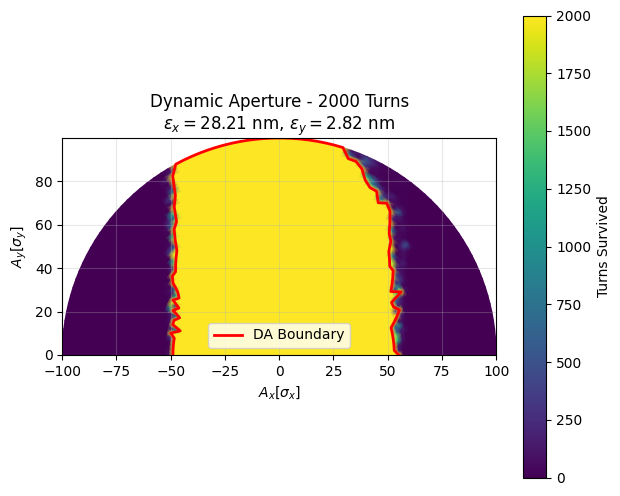

In [ ]:
line = ring  # Assumes 'ring' is your environment from previous cells
line.configure_radiation(model=None) # DA is usually done without radiation or with 'mean'

# Get Twiss and Emittance data
tw = line.twiss4d() 

ex = ring_tw.eq_gemitt_x
ey = ring_tw.eq_gemitt_y


if ey < 1e-13:
    ey = 0.10 * ex

num_turns = 2000 # Increased turns for better accuracy
n_r = 100         # Radial steps
n_theta = 80     # Angular steps

# Generate a polar grid in normalized coordinates (sigmas)
x_norm, y_norm, r_xy, theta_xy = xp.generate_2D_polar_grid(
    r_range=(0, 200),      # Scan out to 60 sigmas
    theta_range=(0, np.pi),
    nr=n_r, ntheta=n_theta
)

# Build and Track Particles
particles = line.build_particles(
    x_norm=x_norm, 
    y_norm=y_norm,
    nemitt_x=line.particle_ref.beta0[0] * line.particle_ref.gamma0[0] * ex,
    nemitt_y=line.particle_ref.beta0[0] * line.particle_ref.gamma0[0] * ey
)
print(f"Tracking {len(particles.x)} particles for {num_turns} turns...")

'''line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))'''

line.track(particles, num_turns=num_turns, with_progress=True)

# Sort particles back to the original grid order
particles.sort(interleave_lost_particles=True)

# Process the Boundary
turn_lost = particles.at_turn.reshape(n_r, n_theta)
x_grid = x_norm.reshape(n_r, n_theta)
y_grid = y_norm.reshape(n_r, n_theta)

# Find the last surviving particle along each angle (theta)
da_x_sig = []
da_y_sig = []

for i_theta in range(n_theta):
    # Get survival for this specific angle
    alive_indices = np.where(turn_lost[:, i_theta] == num_turns)[0]
    if len(alive_indices) > 0:
        last_idx = alive_indices[-1]
        da_x_sig.append(x_grid[last_idx, i_theta])
        da_y_sig.append(y_grid[last_idx, i_theta])
    else:
        da_x_sig.append(0)
        da_y_sig.append(0)



<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
/tmp/mwatson/ipykernel_55435/1596566340.py:14: SyntaxWarning: invalid escape sequence '\e'
  f"$\epsilon_x = {ex*1e9:.2f}$ nm, $\epsilon_y = {ey*1e9:.2f}$ nm")
/tmp/mwatson/ipykernel_55435/1596566340.py:14: SyntaxWarning: invalid escape sequence '\e'
  f"$\epsilon_x = {ex*1e9:.2f}$ nm, $\epsilon_y = {ey*1e9:.2f}$ nm")
/tmp/mwatson/ipykernel_55435/1596566340.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


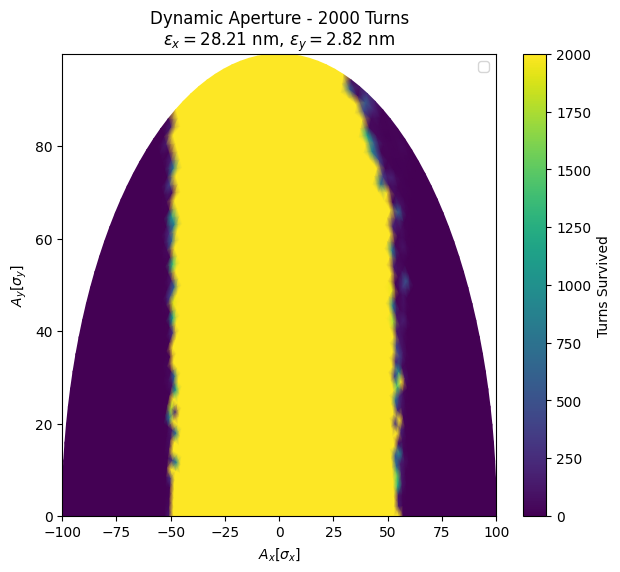

In [ ]:

fig, ax = plt.subplots(figsize=(7, 6))

# Plot the heatmap
pcm = ax.pcolormesh(x_grid, y_grid, turn_lost, shading='gouraud', cmap='viridis')
cb = plt.colorbar(pcm, ax=ax)
cb.set_label('Turns Survived')

# Plot the DA Boundary line
#ax.plot(da_x_sig, da_y_sig, color='red', lw=2, label='DA Boundary')

ax.set_xlabel(r'$A_x [\sigma_x]$')
ax.set_ylabel(r'$A_y [\sigma_y]$')
ax.set_title(f"Dynamic Aperture - {num_turns} Turns\n"
             f"$\epsilon_x = {ex*1e9:.2f}$ nm, $\epsilon_y = {ey*1e9:.2f}$ nm")
#ax.legend()
ax.set_aspect('auto')


plt.savefig('DA_plot_rad_mean.png')